In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import string
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MultipleLocator

from metpy.calc import mixing_ratio_from_relative_humidity,specific_humidity_from_mixing_ratio
from metpy.units import units

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def get_df_from_nc(file, var, loc_sel=None):
    ds = xr.open_dataset(file)
    df = pd.DataFrame(ds[var].values, columns=ds.location, index=pd.to_datetime(ds.time,utc=True))[dt_from:dt_to]
    if loc_sel is None:
        return df
    else:
        return df[loc_sel]

## Script settings

In [3]:
#h='2m'
h='5m'

#scope ='H2'
scope ='H3'

In [4]:
# do scope specific settings
if scope == 'H2':   
    scope_name = 'HEFEX II'
    hlines_temp = [2,1]  # positions from below [dotted, solid]
    hlines_qv = [1,None]  # positions from below [dotted, solid]
    
    # Define locations for variable
    loc_temp = ['D316','A309','D305','T303','D293','D285','D281','T275','D273','D269','A267','A267R','A267L','D262','A260','A255','STHE']
    loc_qv = ['A309','T303','T275','A267','A267R','A267L','A260','A255']

    dt_from,dt_to = '2023-08-17', '2023-09-07 10:00'

    file_obs  = f'HEFEX2__Obs_AWS_L1__1h_avg30min_20230816-20230910.nc'
    file_icon = f'HEFEX2__ICON_v370_2030_aws_locations__1h_avg30min_20230815-20230914.nc'
elif scope == 'H3':
    scope_name = 'HEFEX III'
    hlines_temp = [4,2]  # positions from below [dotted, solid]
    hlines_qv = hlines_temp

    loc_temp = ['T303','T272','A245','A244','STHE','IHE']
    loc_qv = loc_temp

    dt_from,dt_to = '2025-08-06', '2025-08-31 23:59'

    file_obs  = f'HEFEX3__Obs_AWS_L1__1h_avg30min_20250805-20250903.nc'
    file_icon = f'HEFEX3__ICON_v370_2030_aws_locations__1h_avg30min_20250805-20250905.nc'
else:
    print('Unknown scope!')

## Get data (ICON & Obs) and resample to daily

The data used for this figure is available at Zenodo:

HEFEX II: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19568035.svg)](https://doi.org/10.5281/zenodo.19568035)

HEFEX III: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19596032.svg)](https://doi.org/10.5281/zenodo.19596032)

In [5]:
df_temp = get_df_from_nc(data_dir + file_obs, f't_2m', loc_temp)
df_rh   = get_df_from_nc(data_dir + file_obs, f'rh_2m', loc_qv)
df_pres = get_df_from_nc(data_dir + file_obs, f'pres', loc_qv)

df_i_temp = get_df_from_nc(data_dir + file_icon, f't_{h}', loc_temp) - 273.15
df_i_qv   = get_df_from_nc(data_dir + file_icon, f'qv_{h}', loc_qv) * 1000

In [6]:
# filter RH data_in and calculate QV
df_rh[df_rh <= 5] = np.nan

df_w = mixing_ratio_from_relative_humidity(df_pres.values * units.hPa, df_temp[loc_qv].values * units.degC, df_rh.values/100)
df_qv = pd.DataFrame(specific_humidity_from_mixing_ratio(df_w).magnitude * 1000, columns=df_rh.columns, index=df_rh.index)

In [7]:
# apply mask of NaN values in Obs to ICON data_in
df_i_temp = df_i_temp.mask(df_temp.isna())
df_i_qv = df_i_qv.mask(df_qv.isna())

In [8]:
# resample all data_in to 1d
df_temp_d = df_temp.resample('1d').mean()
df_i_temp_d = df_i_temp.resample('1d').mean()
df_qv_d = df_qv.resample('1d').mean()
df_i_qv_d = df_i_qv.resample('1d').mean()

## Create plots

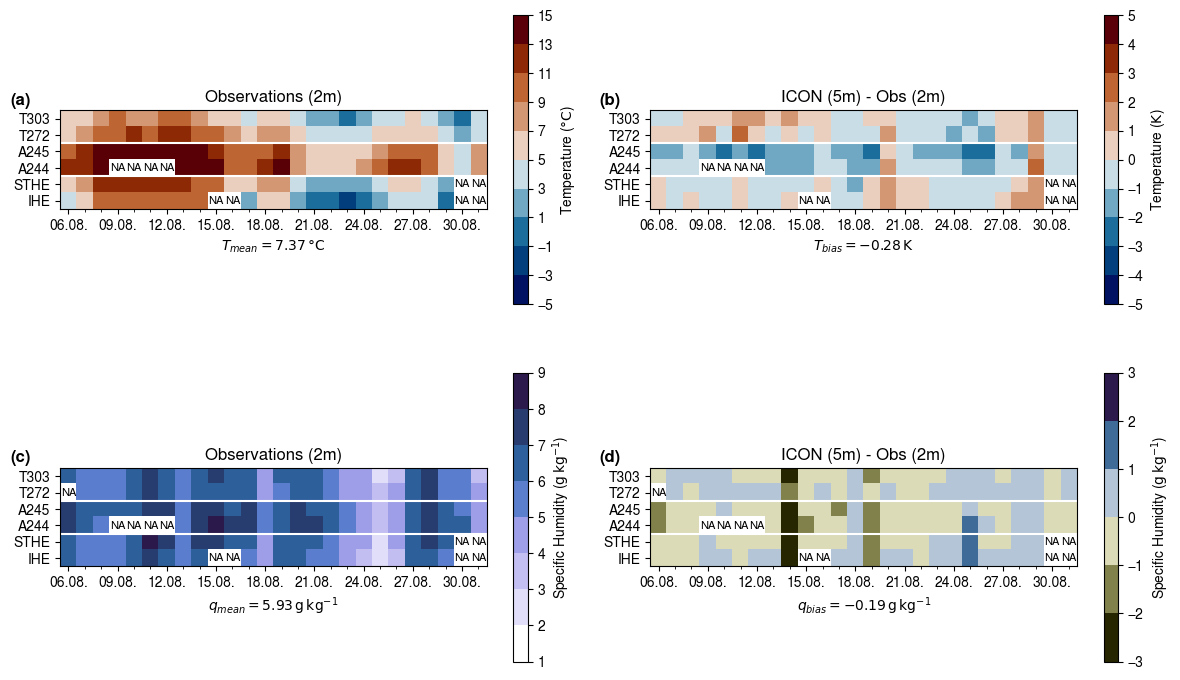

In [9]:
def get_cmap_norm(bounds,cmap):
    cmap = plt.get_cmap(cmap, len(bounds)-1)
    norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)
    return cmap,bounds,norm

def plot_matrix(df,ax,cbar_label):
    im = ax.imshow(df.T, cmap=cmap, norm=norm)
    fig.colorbar(im, ax=ax, shrink=.7, label=cbar_label, boundaries=bounds, ticks=bounds)
    
    # Find NaN locations and add overlay markers
    nan_y, nan_x = np.where(np.isnan(df.T))
    #ax.scatter(nan_x, nan_y, marker="x", c="grey", s=40, linewidths=.5)
    for i, txt in enumerate(nan_x):
        ax.annotate('NA', (nan_x[i], nan_y[i]), va='center',ha='center',fontsize=8)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12,8))

# TEMP: Obs
ny = len(loc_temp)
nx = len(df_temp_d.index)

cmap,bounds,norm = get_cmap_norm(range(-5,16,2), cm.vik)

ax = axs[0][0]
plot_matrix(df_temp_d,ax,'Temperature ($\mathrm{{°C}}$)')
ax.set_title('Observations (2m)')
ax.set_xlabel(fr'$T_{{mean}} = {np.nanmean(df_temp.values):.2f}\,\mathrm{{°C}}$')

# TEMP: ICON-Obs
cmap,bounds,norm = get_cmap_norm(range(-5,6,1), cm.vik)

df_diff = df_i_temp_d-df_temp_d
bias = np.nanmean(df_diff.values).round(2)
ax = axs[0][1]
plot_matrix(df_diff,ax,'Temperature ($\mathrm{{K}}$)')
ax.set_title(f'ICON ({h}) - Obs (2m)')
ax.set_xlabel(fr'$T_{{bias}} = {bias:.2f}\,\mathrm{{K}}$')

for ax in axs[0]:
    ax.set_yticks(range(ny), [loc_temp[i] for i in range(ny)])
    ax.set_xticks(range(0, nx, 3))
    ax.set_xticklabels([df_diff.index[i].strftime('%d.%m.') for i in range(0, nx, 3)])
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    for i,hl in enumerate(hlines_temp):
        if hl is not None:
            ax.axhline(ny-hl-.5, c='white', ls='-', lw=1.5)   

# QV: Obs
ny = len(loc_qv)
nx = len(df_qv_d.index)

cmap,bounds,norm = get_cmap_norm(range(1,10,1), cm.devon_r)

ax = axs[1][0]
plot_matrix(df_qv_d,ax,'Specific Humidity ($\mathrm{{g\,kg^{{-1}}}}$)')
ax.set_title('Observations (2m)')
ax.set_xlabel(fr'$q_{{mean}} = {np.nanmean(df_qv.values):.2f}\,\mathrm{{g\,kg^{{-1}}}}$')

# QV: ICON-Obs
#cmap,bounds,norm = get_cmap_norm(np.arange(-2,2.5,.5), cm.broc_r)
#cmap,bounds,norm = get_cmap_norm(np.arange(-3,3.1,.75), cm.broc_r)
cmap,bounds,norm = get_cmap_norm(np.arange(-3,4,1), cm.broc_r)

df_diff = df_i_qv_d-df_qv_d
bias = np.nanmean(df_diff.values).round(2)
ax = axs[1][1]
plot_matrix(df_diff,ax,'Specific Humidity ($\mathrm{{g\,kg^{{-1}}}}$)')
ax.set_title(f'ICON ({h}) - Obs (2m)')
ax.set_xlabel(fr'$q_{{bias}} = {bias:.2f}\,\mathrm{{g\,kg^{{-1}}}}$')

for ax in axs[1]:
    ax.set_yticks(range(ny), [loc_qv[i] for i in range(ny)])
    ax.set_xticks(range(0, nx, 3))
    ax.set_xticklabels([df_diff.index[i].strftime('%d.%m.') for i in range(0, nx, 3)])
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    for i,hl in enumerate(hlines_qv):
        if hl is not None:
            ax.axhline(ny-hl-.5, c='white', ls='-', lw=1.5)

# panel letters 
for ax, letter in zip(axs.flat, string.ascii_lowercase):
    ax.text(
        -0.07, 1.02, f'({letter})',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='bottom', ha='right'
    )
    
#plt.suptitle(f'{scope_title} - all day')
plt.tight_layout()
plt.savefig(fig_png_dir + f'HEF_Obs_ICON_matrix_{scope}_{h}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_Obs_ICON_matrix_{scope}_{h}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()